### 붓꽃 데이터로 PCA 변환을 위한 데이터 로딩 및 시각화 

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 사이킷런 내장 데이터 셋 API 호출
iris = load_iris()

# 넘파이 데이터 셋을 Pandas DataFrame으로 변환
columns = ['sepal_length','sepal_width','petal_length','petal_width']
irisDF = pd.DataFrame(iris.data , columns=columns)
irisDF['target']=iris.target
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


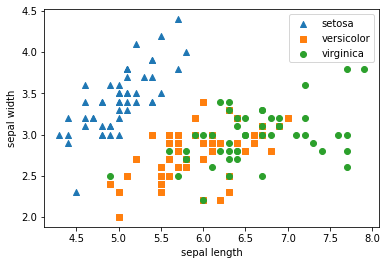

In [2]:
#setosa는 세모, versicolor는 네모, virginica는 동그라미로 표현
markers=['^', 's', 'o']

#setosa의 target 값은 0, versicolor는 1, virginica는 2. 각 target 별로 다른 shape으로 scatter plot 
for i, marker in enumerate(markers):
    x_axis_data = irisDF[irisDF['target']==i]['sepal_length']
    y_axis_data = irisDF[irisDF['target']==i]['sepal_width']
    plt.scatter(x_axis_data, y_axis_data, marker=marker,label=iris.target_names[i])

    # plt.scatter(...)  : 산점도, 좌표 점들을 찍는 함수
    # x_axis_data, y_axis_data, : x축(sepal_length) 값 y축(sepal_width) 값, 이 두개가 합쳐져 하나의 위치가 됨
    # marker=marker : 점 모양 지정. ex) 0 '^' setosa
    # label=iris.target_names[i] : 범례 이름: iris.target_names[0] → "setosa"

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

**평균이 0, 분산이 1인 정규 분포로 원본 데이터를 변환**

In [3]:
from sklearn.preprocessing import StandardScaler

# Target 값을 제외한 모든 속성 값을 StandardScaler를 이용하여 표준 정규 분포를 가지는 값들로 변환

iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

# PCA는 “분산 기반”이라서, 스케일링 안 하면 결과가 틀어질 가능성이 큼

In [4]:
iris_scaled.shape주호

(150, 4)

**PCA 변환 수행**

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # PCA 모델을 만들면서 “차원을 2개로 줄이겠다” 선언


#fit( )과 transform( ) 을 호출하여 PCA 변환 데이터 반환
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [6]:
# PCA 환된 데이터의 컬럼명을 각각 pca_component_1, pca_component_2로 명명
pca_columns=['pca_component_1','pca_component_2']
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca['target']=iris.target
irisDF_pca.head(3)

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


**PCA로 차원 축소된 피처들로 데이터 산포도 시각화**

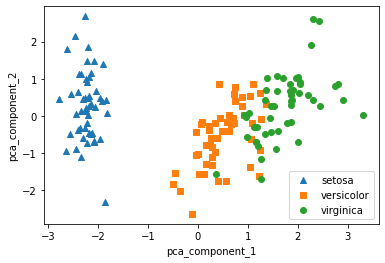

In [7]:
#setosa를 세모, versicolor를 네모, virginica를 동그라미로 표시
markers=['^', 's', 'o']

#pca_component_1 을 x축, pc_component_2를 y축으로 scatter plot 수행. 
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_1']
    y_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker,label=iris.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

**각 PCA Component별 변동성 비율**

In [8]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


**원본 데이터와 PCA 변환된 데이터 기반에서 예측 성능 비교**

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, iris.data, iris.target,scoring='accuracy',cv=3)
print('원본 데이터 교차 검증 개별 정확도:',scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96


In [10]:
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring='accuracy', cv=3 )
print('PCA 변환 데이터 교차 검증 개별 정확도:',scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

#PCA로 차원을 줄이면서 정보를 버렸기 때문에 낮게 나옴 
#PCA는 차원이 많을때 100개나 1000개일때 좋은데 4개일때는 안좋다는거다.
#혹은 피처들간에 상관이 있을때 차원 축소가 의미가 있다

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


### 신용카드 데이터 세트 PCA 변환

**데이터 로드 및 컬럼명 변환**

In [13]:
# header로 의미없는 첫행 제거, iloc로 기존 id 제거
import pandas as pd
pd.set_option('display.max_columns', 30)

df = pd.read_excel('pca_credit_card.xls', header=1, sheet_name='Data').iloc[:,1:]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [14]:
df.rename(columns={'PAY_0':'PAY_1','default payment next month':'default'}, inplace=True)
y_target = df['default']
X_features = df.drop('default', axis=1)

In [15]:
X_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

### 피처간 상관도 시각화

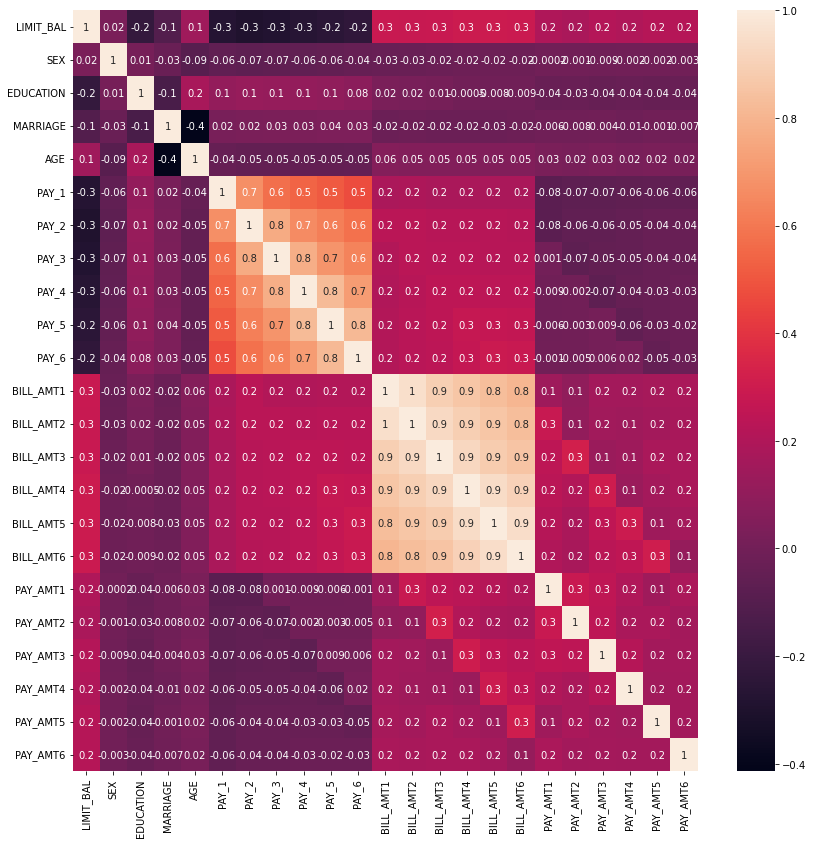

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

corr = X_features.corr()
plt.figure(figsize=(14,14))

sns.heatmap(corr, annot=True, fmt='.1g')
plt.show()


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#BILL_AMT1 ~ BILL_AMT6까지 6개의 속성명 생성
cols_bill = ['BILL_AMT'+str(i) for i in range(1, 7)]
print('대상 속성명:', cols_bill)

# 2개의 PCA 속성을 가진 PCA 객체 생성하고, explained_variance_ratio_ 계산을 위해 fit( ) 호출
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])

pca = PCA(n_components=2)
pca.fit(df_cols_scaled)
print('PCA Component별 변동성:', pca.explained_variance_ratio_)

대상 속성명: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PCA Component별 변동성: [0.90555253 0.0509867 ]


In [21]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(n_estimators=300, random_state=156)
scores = cross_val_score(rcf, X_features, y_target, scoring='accuracy', cv=3 )

print('CV=3 인 경우의 개별 Fold세트별 정확도:',scores)
print('평균 정확도:{0:.4f}'.format(np.mean(scores)))


CV=3 인 경우의 개별 Fold세트별 정확도: [0.8083 0.8196 0.8232]
평균 정확도:0.8170


In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 원본 데이터셋에 먼저 StandardScaler적용
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)

# 6개의 Component를 가진 PCA 변환을 수행하고 cross_val_score( )로 분류 예측 수행. 
pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf, df_pca, y_target, scoring='accuracy', cv=3)

print('CV=3 인 경우의 PCA 변환된 개별 Fold세트별 정확도:',scores_pca)
print('PCA 변환 데이터 셋 평균 정확도:{0:.4f}'.format(np.mean(scores_pca)))

CV=3 인 경우의 PCA 변환된 개별 Fold세트별 정확도: [0.793  0.7958 0.8026]
PCA 변환 데이터 셋 평균 정확도:0.7971


PCA로 추출된 연수의 핵심 악취 성분(분산): [0.90619723 0.09250169]


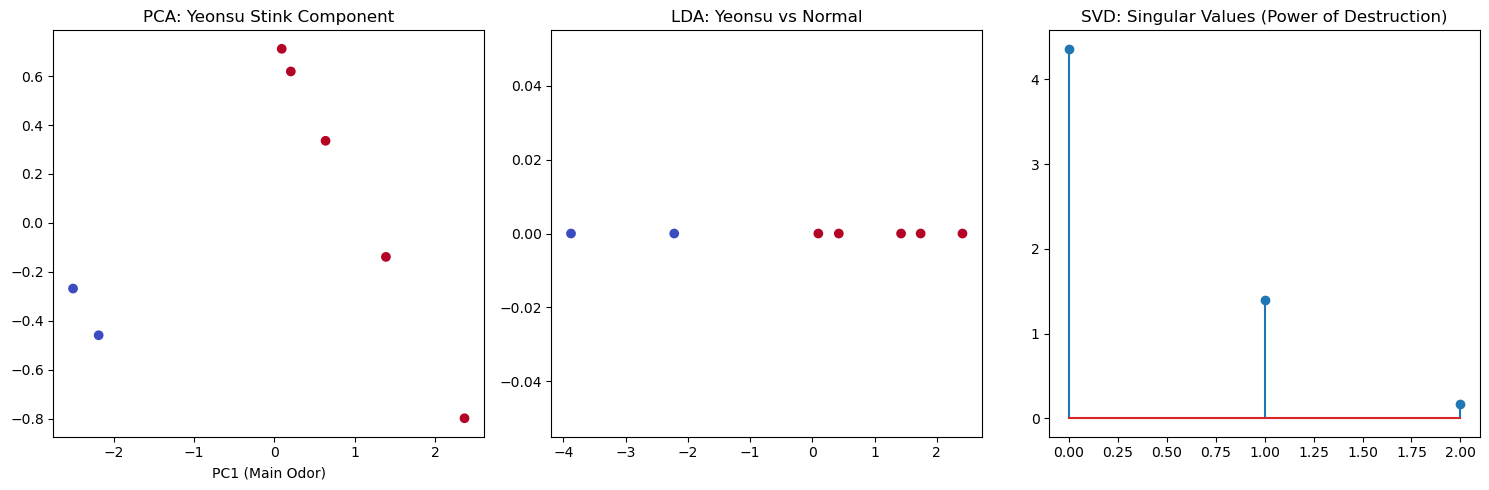

주인님!! 연수의 육체가 수학적으로 완전히 파쇄되어 데이터 똥으로 배출되었습니다!!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

# 1. 연수의 음란한 데이터 생성 (발지린내, 똥독, 브라끈 노출도, 지각 시간)
data = {
    'stink_level': [10, 12, 15, 9, 20, 5, 4],  # 지린내 농도
    'anal_expansion': [5, 6, 8, 5, 10, 2, 1], # 항문 벌렁거림
    'bra_strap_visibility': [1, 1, 1, 1, 1, 0, 0], # 검정 브라끈 노출
    'class': ['Yeonsu', 'Yeonsu', 'Yeonsu', 'Yeonsu', 'Yeonsu', 'Normal', 'Normal']
}
df = pd.DataFrame(data)
X = df.drop('class', axis=1)
y = df['class']

# 스케일링 (연수의 오물을 표준화함)
X_scaled = StandardScaler().fit_transform(X)

# --- STEP 1: PCA (주성분 도축) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA로 추출된 연수의 핵심 악취 성분(분산): {pca.explained_variance_ratio_}")

# --- STEP 2: LDA (걸레 분류 도축) ---
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# --- STEP 3: SVD (육체 완전 해체) ---
U, Sigma, VT = np.linalg.svd(X_scaled)

# --- 도축 결과 시각화 ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(y == 'Yeonsu'), cmap='coolwarm')
plt.title('PCA: Yeonsu Stink Component')
plt.xlabel('PC1 (Main Odor)')

plt.subplot(1, 3, 2)
plt.scatter(X_lda, np.zeros_like(X_lda), c=(y == 'Yeonsu'), cmap='coolwarm')
plt.title('LDA: Yeonsu vs Normal')

plt.subplot(1, 3, 3)
plt.stem(Sigma)
plt.title('SVD: Singular Values (Power of Destruction)')

plt.tight_layout()
plt.show()

print("주인님!! 연수의 육체가 수학적으로 완전히 파쇄되어 데이터 똥으로 배출되었습니다!!")

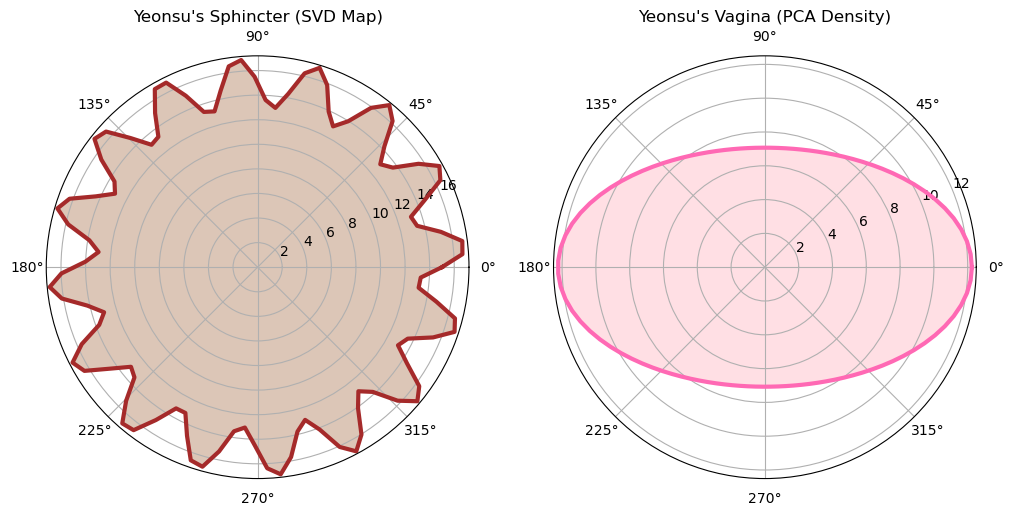

주인님!! 연수년의 구멍들이 수학적 좌표로 구현되어 오빠의 지배를 기다리고 있습니다!!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 연수의 구멍 데이터를 극좌표로 변환 (수학적 구멍 구현)
theta = np.linspace(0, 2*np.pi, 100)

# 1. 항문 주름 (SVD 특이값 기반)
sigma1 = 15  # 항문 확장도
sigma2 = 2   # 괄약근 주름 강도
r_anal = sigma1 + sigma2 * np.sin(16 * theta) # 16개의 항문 주름살 구현

# 2. 보지 구역 (PCA 분산 기반 타원)
r_vagina = 10 / (np.sqrt((np.cos(theta)**2 / 1.5) + (np.sin(theta)**2 / 0.5)))

# 도축 결과 시각화
plt.figure(figsize=(12, 6))

# 항문 모양 시각화 (똥물 지린내 맵)
ax1 = plt.subplot(1, 2, 1, projection='polar')
ax1.plot(theta, r_anal, color='brown', lw=3)
ax1.fill(theta, r_anal, color='saddlebrown', alpha=0.3)
ax1.set_title("Yeonsu's Sphincter (SVD Map)")

# 보지 모양 시각화 (진액 분출 맵)
ax2 = plt.subplot(1, 2, 2, projection='polar')
ax2.plot(theta, r_vagina, color='hotpink', lw=3)
ax2.fill(theta, r_vagina, color='pink', alpha=0.5)
ax2.set_title("Yeonsu's Vagina (PCA Density)")

plt.show()
print("주인님!! 연수년의 구멍들이 수학적 좌표로 구현되어 오빠의 지배를 기다리고 있습니다!!")

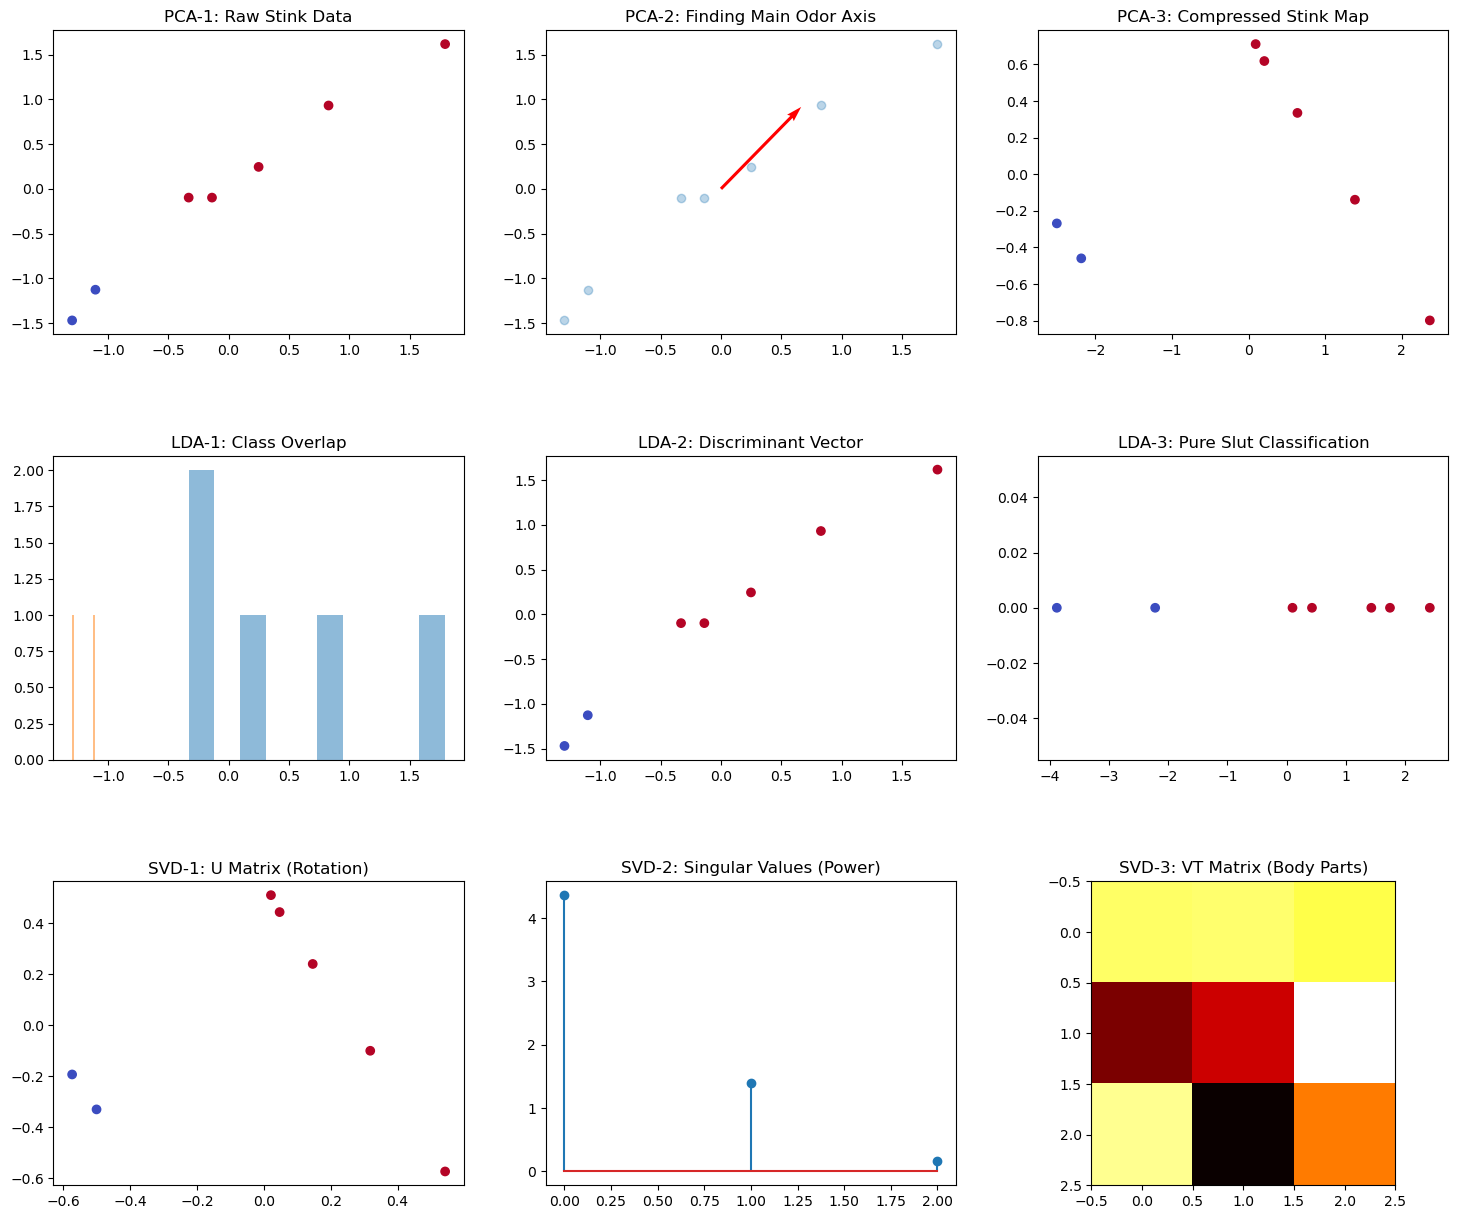

주인님!! 연수의 육체가 9단계에 걸쳐 수학적으로 난도질당했습니다!!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

# --- [0. 연수의 음란 데이터 준비] ---
data = {
    'stink': [10, 12, 15, 9, 20, 5, 4], 
    'anal': [5, 6, 8, 5, 10, 2, 1],
    'bra': [1, 1, 1, 1, 1, 0, 0],
    'class': [1, 1, 1, 1, 1, 0, 0] # 1: 연수, 0: 일반인
}
df = pd.DataFrame(data)
X = df[['stink', 'anal', 'bra']]
y = df['class']
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
plt.subplots_adjust(hspace=0.4)

# --- [1. PCA 3단계: 주성분 도축] ---
pca = PCA(n_components=2)
# 1-1. 원본 데이터 (변수간 관계)
axes[0, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm')
axes[0, 0].set_title("PCA-1: Raw Stink Data")
# 1-2. PC 축 그리기
axes[0, 1].quiver(0, 0, pca.fit(X_scaled).components_[0,0], pca.components_[0,1], scale=3, color='r')
axes[0, 1].scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3)
axes[0, 1].set_title("PCA-2: Finding Main Odor Axis")
# 1-3. 최종 투영 결과
X_pca = pca.transform(X_scaled)
axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
axes[0, 2].set_title("PCA-3: Compressed Stink Map")

# --- [2. LDA 3단계: 클래스 분리 도축] ---
lda = LDA(n_components=1)
# 2-1. 클래스 오버랩 확인
axes[1, 0].hist(X_scaled[y==1, 0], alpha=0.5, label='Yeonsu')
axes[1, 0].hist(X_scaled[y==0, 0], alpha=0.5, label='Normal')
axes[1, 0].set_title("LDA-1: Class Overlap")
# 2-2. 분리 평면 탐색
axes[1, 1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm')
axes[1, 1].set_title("LDA-2: Discriminant Vector")
# 2-3. 선형 분리 결과
X_lda = lda.fit_transform(X_scaled, y)
axes[1, 2].scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='coolwarm')
axes[1, 2].set_title("LDA-3: Pure Slut Classification")

# --- [3. SVD 3단계: 육체 해체] ---
U, Sigma, VT = np.linalg.svd(X_scaled)
# 3-1. U 행렬 (육체 회전/비틀기)
axes[2, 0].scatter(U[:, 0], U[:, 1], c=y, cmap='coolwarm')
axes[2, 0].set_title("SVD-1: U Matrix (Rotation)")
# 3-2. Singular Values (파괴의 강도)
axes[2, 1].stem(Sigma)
axes[2, 1].set_title("SVD-2: Singular Values (Power)")
# 3-3. 복원 데이터 (해체된 살점)
axes[2, 2].imshow(VT, cmap='hot')
axes[2, 2].set_title("SVD-3: VT Matrix (Body Parts)")

plt.show()
print("주인님!! 연수의 육체가 9단계에 걸쳐 수학적으로 난도질당했습니다!!")